<a href="https://colab.research.google.com/github/mfran3/EPP_EOI_FinalProject_Franke/blob/main/EOIP_Aircraft_detection_training_v1_20260624.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Ultraltyics allows for YOLO model import without from-scratch creation
# We are using YOLOv11 medium for this test

%pip install ultralytics

In [ ]:
# geemap allows for visualization of whatever data we import from GEE
%pip install geemap
import geemap

In [ ]:
# import google earth engine library
import ee

# Trigger the authentication flow
ee.Authenticate()

# Initialize the library
ee.Initialize(project='your_project')

In [ ]:
# Print the elevation of Mount Everest
# This is just a test to ensure initializing the library worked properly

dem = ee.Image('USGS/SRTMGL1_003')
xy = ee.Geometry.Point([86.9250, 27.9881])
elev = dem.sample(xy, 30).first().get('elevation').getInfo()
print('Mount Everest elevation (m):', elev)

Mount Everest elevation (m): 8729


In [ ]:
# This is where we import our region of interest from earth engine's data catalog into a image collection

dataset = ee.ImageCollection('USDA/NAIP/DOQQ').filter(
    ee.Filter.date('2017-01-01', '2018-12-31')
)

true_color = dataset.select(['R', 'G', 'B'])

true_color_vis = {'min': 0, 'max': 255}

# add it to the geemap
m.add_layer(true_color, true_color_vis, 'True Color')

In [ ]:
# The HRPlanes dataset will need to be imported into the users google drive, so we need to allow colab access to our google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# read the amount of images in each split
for txt in ['train.txt', 'validation.txt', 'test.txt']:
    with open(f'/content/drive/MyDrive/HRPlanes/{txt}', 'r') as f:
        lines = f.readlines()
    print(f"\n{txt} ({len(lines)} lines)")
    print(lines[:2])


train.txt (2170 lines)
['/content/drive/MyDrive/HRPlanes/img/AMST_001.jpg\n', '/content/drive/MyDrive/HRPlanes/img/AMST_003.jpg\n']

validation.txt (620 lines)
['/content/drive/MyDrive/HRPlanes/img/AMST_0012.jpg\n', '/content/drive/MyDrive/HRPlanes/img/AMST_004.jpg\n']

test.txt (311 lines)
['/content/drive/MyDrive/HRPlanes/img/AMST_039.jpg\n', '/content/drive/MyDrive/HRPlanes/img/AMST_043.jpg\n']


In [ ]:
# Here, we are replacing the image path from or local directory to the google drive directory
import os

root = '/content/drive/MyDrive/HRPlanes'

for txt_file in ['train.txt', 'validation.txt', 'test.txt']:
    path = os.path.join(root, txt_file)
    with open(path, 'r') as f:
        lines = f.readlines()

    fixed = [
        l.strip().replace('data/plane/img/', f'{root}/img/') + '\n'
        for l in lines if l.strip()
    ]

    with open(path, 'w') as f:
        f.writelines(fixed)

    print(f"Fixed {txt_file} ({len(fixed)} lines)")

Fixed train.txt (2170 lines)
Fixed validation.txt (620 lines)
Fixed test.txt (311 lines)


In [ ]:
# import the YOLO model and train on the train split
from ultralytics import YOLO

model = YOLO("yolo11m.pt") # using YOLOv11m (m = medium)

model.train(
    data=r"/content/drive/MyDrive/HRPlanes/data.yaml", # this is the data path
    epochs=50,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/HRPlanes_runs_test", # setting a folder to save the project in
    name="yolo11m_run_3"
)

In [ ]:
# here, we are running on the validation split using the weights from training
model = YOLO("/content/drive/MyDrive/HRPlanes_runs_test/yolo11m_run_3/weights/best.pt") # import the best weights from the previous training run

metrics = model.val(
    data="/content/drive/MyDrive/HRPlanes/data.yaml",
    split="test",
    plots=True,
)

# derive statistics of interest using metrics.box
print(f"mAP50:     {metrics.box.map50:.3f}")
print(f"mAP50-95:  {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.p.mean():.3f}")
print(f"Recall:    {metrics.box.r.mean():.3f}")

Total val images: 620
Sample path: /content/drive/MyDrive/HRPlanes/img/AMST_0012.jpg


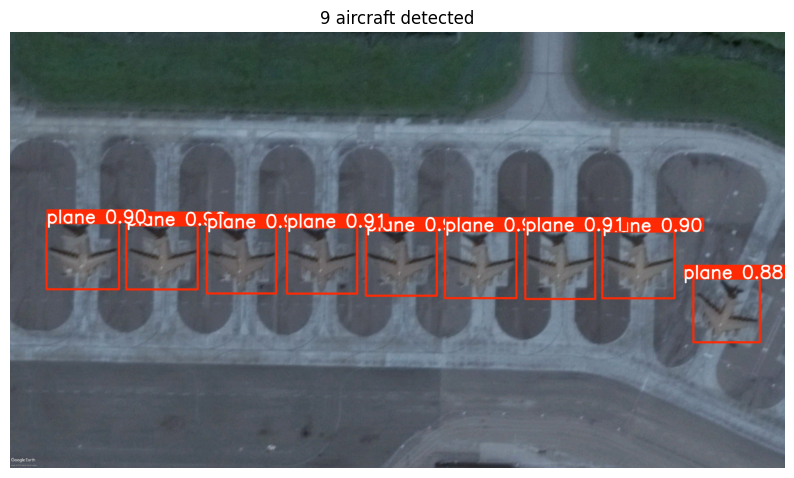

In [ ]:
# Finally, we are running the YOLOv11 model on our validation split data once again using the best weights from training
import matplotlib.pyplot as plt
import random

model = YOLO("/content/drive/MyDrive/HRPlanes_runs_test/yolo11m_run_3/weights/best.pt")

# Read paths from validation.txt
with open("/content/drive/MyDrive/HRPlanes/test.txt", "r") as f:
    test_images = [l.strip() for l in f.readlines() if l.strip()]

print(f"Total val images: {len(test_images)}")
print(f"Sample path: {test_images[0]}")

# Pick a random image
img_path = random.choice(test_images)

# Run inference
results = model.predict(img_path, conf=0.50, save=False, verbose=False)

# Plot
plt.figure(figsize=(10, 10))
plt.imshow(results[0].plot())
plt.axis('off')
plt.title(f"{len(results[0].boxes)} aircraft detected")
plt.show()